

# Introduction
Welcome to todays lab session where we will focus on perceptron learning algorithm.
The easiest way to complete this session is to log into a Google account and save a copy to your google drive. Alternatively, you could save this document to your machine and open as a Jupyter notebook. This lab only requires 2 external libraries, matplotlib and numpy.


In [32]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

Generate input data randomly (50 + and 50 -)


In [33]:
X1=np.concatenate((np.random.rand(1,50),np.random.rand(1,50),np.ones((1,50))))  # class '-1'
X2=np.concatenate((np.random.rand(1,50),1.5+np.random.rand(1,50),np.ones((1,50)))) # class '+1'
X=np.concatenate((X1,X2),axis=1)
print(X1)
print(X2)
print(X)

[[0.69645266 0.97266461 0.0333112  0.64255662 0.65077563 0.66608492
  0.95946934 0.60134947 0.34116986 0.12709946 0.68074988 0.3066472
  0.63818077 0.09728145 0.95533039 0.02041346 0.34942493 0.56431057
  0.36143948 0.93010449 0.98627429 0.95586804 0.81741864 0.90653688
  0.77257023 0.79965673 0.23970566 0.84510518 0.16167096 0.10579681
  0.14076713 0.1169811  0.45790782 0.19385004 0.54025814 0.76576505
  0.18656573 0.36530642 0.33600628 0.72889422 0.91857281 0.79605406
  0.00999743 0.47506493 0.81515546 0.83761721 0.45078524 0.77442618
  0.5383465  0.20517982]
 [0.71951638 0.89507386 0.37223281 0.56435324 0.14753887 0.77536414
  0.78338007 0.36467893 0.27674639 0.79635288 0.59368017 0.72728968
  0.0686267  0.14305819 0.08782898 0.05718215 0.55484741 0.18696506
  0.22301468 0.0610864  0.96802779 0.43800548 0.85834668 0.30780031
  0.86009786 0.50524588 0.44325176 0.58548888 0.08578422 0.73255317
  0.97788295 0.10833759 0.27094894 0.8724439  0.32896582 0.25722954
  0.59122217 0.14016095 

Output class [-1,+1]

In [34]:
Y=np.concatenate((-np.ones((50,)),np.ones((50,))));
print(Y)

[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]


Initial weight vector - will be updated by the learning algorithm

In [35]:
w=np.array([.0,.0,.0])
print(w)

[0. 0. 0.]


Call **perceptron learning algorithm**

In [36]:
#This code was adapted from N. Quadrianto. All rights reserved. 

def slperceptron(X,Y,w_init,iter):
  #a single layer perceptron learning algorithm
  #4 parameters: 
  #  X is the set of training instances
  #  Y is the set of class labels for the training instances
  #  w_init is an initial weight vector
  #  iter is the number of interations the algorithm will run for
  w = w_init  
  for iteration in range(iter):  #<- in practice, use some stopping criterion!
    for ii in range(X.shape[1]): #cycle through training set
      if np.sign(np.dot(w,X[:,ii]))!=Y[ii]: #wrong decision?
          w = w + X[:,ii] * Y[ii]   #then add (or subtract) this point to w

    l=-Y*np.dot(w, X);
    loss=sum(l[l>0])/X.shape[1]; 
    print("Loss at epoch",iteration+1, ": ", loss)
  return w


In [37]:
wtag=slperceptron(X,Y,w,5);
print ("solution:", wtag)


Loss at epoch 1 :  0.11758682117208981
Loss at epoch 2 :  0.23517364234417962
Loss at epoch 3 :  0.5360237425890693
Loss at epoch 4 :  0.13791541521712547
Loss at epoch 5 :  0.3504425940346362
solution: [-1.15023617  3.93740889 -1.        ]


**Predict** classes

In [38]:
ytag=np.dot(wtag,X)
print(ytag)

[ 1.03194518  1.40547778  0.42731702  0.4829976  -1.16762483  1.28677071
  0.9808713  -0.25580386 -0.30276221  1.9893725   0.55453847  1.51092016
 -1.46384723 -0.54861804 -1.75303695 -0.7983308   0.78273993 -0.91293253
 -0.53764076 -1.8293177   1.67707287 -0.37486734  1.43943739 -0.83079582
  1.49791876  0.06956553  0.46954528  0.33323859 -0.84819225  1.76267005
  2.68840959 -0.70798651 -0.45986536  2.21219506 -0.3261515  -0.86799278
  1.1132888  -0.86831767  0.12110432  1.60361342  1.84233238  1.85625969
  0.69176049  1.57860653  0.37917624 -1.93140567  0.62153497  2.02751306
  0.6060657  -1.08004223  5.15249912  5.3580939   6.00780083  7.70323534
  4.56460198  5.80545035  7.2735346   6.05430223  4.15973918  5.42653597
  7.14504273  5.51611076  4.66951611  4.30993151  7.28587646  5.91659337
  7.4376372   6.98258484  4.67553852  6.254449    6.52755677  5.93629083
  7.6057541   7.4828424   6.19718412  6.97488862  6.53970674  5.53944144
  7.54620773  5.25127563  6.61319695  5.20421551  7

**Calculate** number of incorrect predictions

In [39]:
errors = np.sum(np.sign(ytag)!=Y)
print("errors %.2f"%errors)

errors 30.00


Plot predictions over original data

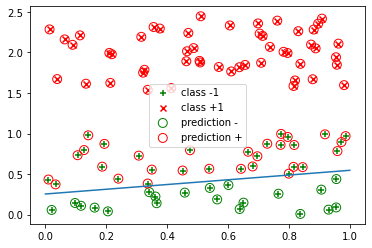

In [40]:
plt.scatter(X1[0,:],X1[1,:],c="g",marker="+",label="class -1")
plt.scatter(X2[0,:],X2[1,:],c="r",marker="x",label="class +1")

plt.scatter(X[0,ytag<0],X[1,ytag<0],s=80, facecolors='none', edgecolors='g',label="prediction -")
plt.scatter(X[0,ytag>0],X[1,ytag>0],s=80, facecolors='none', edgecolors='r',label="prediction +")

#show linear classification boundary
xcoord = np.array([0.0,1.0])
ycoord = (wtag[0]*xcoord + wtag[2])/-wtag[1];
plt.plot(xcoord,ycoord)
plt.legend()
plt.show()

# Training a linear perceptron model

1. Take a look at the data generation, and make this linear classification task harder by bringing data points from the two classes closer (modify X2). Did the error rate change?
2.  Iterations as defined in *slperceptron* are also known as epochs. One epoch is one full cycle through the training data. How many epochs do we need to find a solution?
3. Add a line of code to compute the hinge loss value at the beginning of the training and after the SGD updates,e.g. per epoch. Does the loss function decrease or increase over time? 


Solution to 3:

In [46]:
l=-Y*np.dot(wtag,X);
loss=sum(l[l>0])/X.shape[1]; 
print(loss)

0.3504425940346362
